In [39]:
import numpy as np
import pandas as pd
import pickle
from calculate_sds import find_recipe_repetitions
from utils import fped_codes
sampling_batch_size = 10000

In [57]:
with open('data/burgers_step8.pkl', 'rb') as f:
    recipes, ingr_names, calorie_database = pickle.load(f)
n_ingr = len(ingr_names)
fped = pd.read_excel('data/FPED_1718.xlsx', sheet_name="FPED_1718", index_col='FOODCODE')

with open('data/ingredient_nutrient_info.pkl', 'rb') as f:
    nutrient_names, rdvs, ingredient_nutrients = pickle.load(f)

/Users/vtac/vtenv/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [90]:
# Calculate HEI scores for the training data
def hei_calculator(recipes):
    out = []
    hei_list = []
    for recipe in recipes:
        # Normalize by 1000 calories
        calories = 0
        for ingr, qty in zip(ingr_names, recipe):
            calories_per_gram = calorie_database[ingr]
            calories += qty * calories_per_gram
        recipe = recipe/calories*1000

        f_total = 0 # total fruits
        v_total = 0 # total vegetables
        v_greens_beans = 0 # greens and beans
        g_whole = 0 # whole grains
        d_total = 0 # total dairy
        pf_total = 0 # total protein foods
        pf_seafd_plant = 0 # total seafood and plant proteins
        pufa_mufa = 0 # polyunsaturaed fats and monounsaturated fats
        sfa = 0 # saturated fats
        g_refined = 0 # refined grains
        sodium = 0 # sodium? sounds like sodium
        add_sugars = 0 # added sugars

        for i, qty in enumerate(recipe):
            ingr = ingr_names[i]
            if ingr in fped_codes:
                fped_code = fped_codes[ingr]
                fped_data = fped.loc[fped_code]

                f_total+= fped_data['F_TOTAL (cup eq.)']/100*qty
                v_total+= fped_data['V_TOTAL (cup eq.)']/100*qty
                v_greens_beans+= fped_data['V_DRKGR (cup eq.)']/100*qty
                v_greens_beans+= fped_data['V_LEGUMES (cup eq.)']/100*qty
                g_whole+= fped_data['G_WHOLE (oz. eq.)']/100*qty
                d_total+= fped_data['D_TOTAL (cup eq.)']/100*qty
                pf_total+= fped_data['PF_TOTAL (oz. eq.)']/100*qty
                pf_seafd_plant+= fped_data['PF_SOY (oz. eq.)']/100*qty
                pf_seafd_plant+= fped_data['PF_NUTSDS (oz. eq.)']/100*qty
                pf_seafd_plant+= fped_data['PF_LEGUMES (oz. eq.)']/100*qty
                g_refined+= fped_data['G_REFINED (oz. eq.)']/100*qty
                add_sugars+= fped_data['ADD_SUGARS (tsp. eq.)']/100*qty

            idx_pufa = np.where(np.array(nutrient_names) == 'polyunsaturated')[0][0]
            idx_mufa = np.where(np.array(nutrient_names) == 'monounsaturated')[0][0]
            idx_sfa = np.where(np.array(nutrient_names) == ' saturated')[0][0]
            pufa_mufa+= ingredient_nutrients[i, idx_pufa]*qty
            pufa_mufa+= ingredient_nutrients[i, idx_mufa]*qty
            sfa+= ingredient_nutrients[i, idx_sfa]*qty

            idx_sodium = np.where(np.array(nutrient_names) == 'sodium')[0][0]
            sodium+= ingredient_nutrients[i, idx_sodium]*qty
        out.append([f_total, v_total, v_greens_beans, g_whole, d_total, pf_total, pf_seafd_plant, pufa_mufa, sfa, g_refined, sodium, add_sugars])

        # Now calculate HEI scores
        hei = 0
        # total fruits: 0 - 0.8 cup equivalents
        hei+= np.clip((f_total - 0) / (0.8 - 0) * 5, 0, 5) # assigns 0 to 0 or below, 5 to 0.8 or above, and scales linearly in between
        # whole fruits: Assume all fruits in our recipes are whole
        hei+= np.clip((f_total - 0) / (0.4 - 0) * 5, 0, 5)
        # total vegetables: 0 - 1.1 cup equivalents
        hei+= np.clip((v_total - 0) / (1.1 - 0) * 5, 0, 5)
        # greens and beans: 0 - 0.2 cup equivalents
        hei+= np.clip((v_greens_beans - 0) / (0.2 - 0) * 5, 0, 5)
        # whole grains: 0 - 1.5 oz equivalents
        hei+= np.clip((g_whole - 0) / (1.5 - 0) * 10, 0, 10)
        # dairy: 0 - 1.3 cup equivalents
        hei+= np.clip((d_total - 0) / (1.3 - 0) * 10, 0, 10)
        # total protein foods: 0 - 2.5 oz equivalents
        hei+= np.clip((pf_total - 0) / (2.5 - 0) * 5, 0, 5)
        # seafood and plant proteins: 0 - 0.8 cup equivalents
        hei+= np.clip((pf_seafd_plant - 0) / (0.8 - 0) * 5, 0, 5)
        # (pufa+mufa)/sfa: 1.2 - 2.5
        hei+= np.clip((v_total - 1.2) / (2.5 - 1.2) * 10, 0, 10)
        # In the moderation part below, scores are inversely proportional
        # refined grains: 1.8 - 4.3
        hei+= np.clip((4.3 - g_refined)/(4.3 - 1.8)*10, 0, 10)
        # sodium: 1.1 - 2 g
        hei+= np.clip((2 - sodium)/(2 - 1.1)*10, 0, 10)
        # added sugars: 6.5% to 26% of total energy
        add_sugars_energy = add_sugars*4
        add_sugars_percent = add_sugars_energy/1000*100 # each recipe is 1000 calories.
        hei+= np.clip((26 - add_sugars_percent)/(26 - 6.5)*10, 0, 10)
        # saturated fats: 8% - 16% of total energy
        sfa_energy = sfa*9
        sfa_percent = sfa_energy/1000*100
        hei+= np.clip((16 - sfa_percent)/(16 - 8)*10, 0, 10)

        hei_list.append(hei)
    return np.array(hei_list), np.array(out)


In [91]:
hei, out = hei_calculator(recipes)

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

[Text(0.5, 0, 'HEI score [0-100]'),
 Text(0.5, 1.0, 'HEI scores of training recipes')]

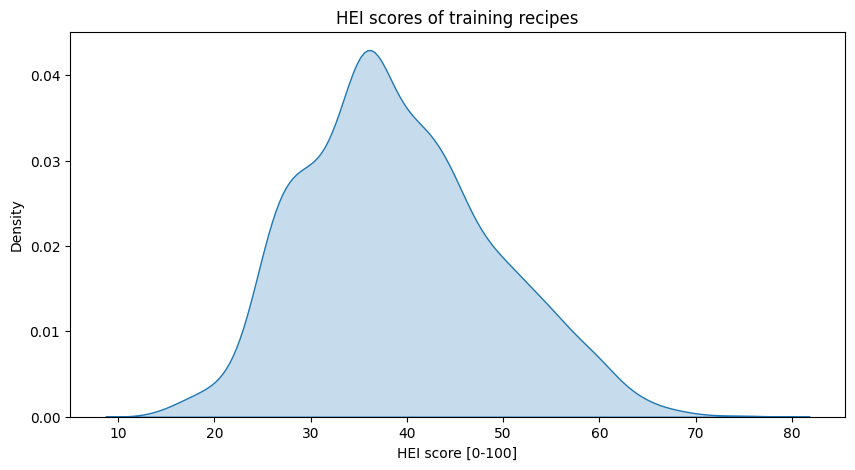

In [94]:
fig, ax = plt.subplots(figsize=(10,5))
sns.kdeplot(hei, fill=True, ax = ax)
ax.set(xlabel='HEI score [0-100]', title='HEI scores of training recipes')